In [1]:
# # IMPORTS
# !py install lightgbm imbalanced-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# PROBLEM DEFINITION
# - Road accident data in Sri Lanka is scattered,
# unstructured, and not readily available in a
# format suitable for analytical or predictive
# purposes. There is no systematic way to
# identify high-risk locations, peak accident
# times, or predict future accident occurrences.
# This makes it difficult for authorities to allocate
# resources effectively for accident prevention.


df = pd.read_csv("accidents_clean_en.csv")

(4314, 19)
Column names Index(['id', 'date', 'time', 'year', 'month', 'day', 'hour', 'day_of_week',
       'district', 'city', 'latitude', 'longitude', 'deaths_count',
       'weather_code', 'temp_max', 'temp_min', 'temp_mean', 'windgusts_max',
       'humidity_mean'],
      dtype='object')


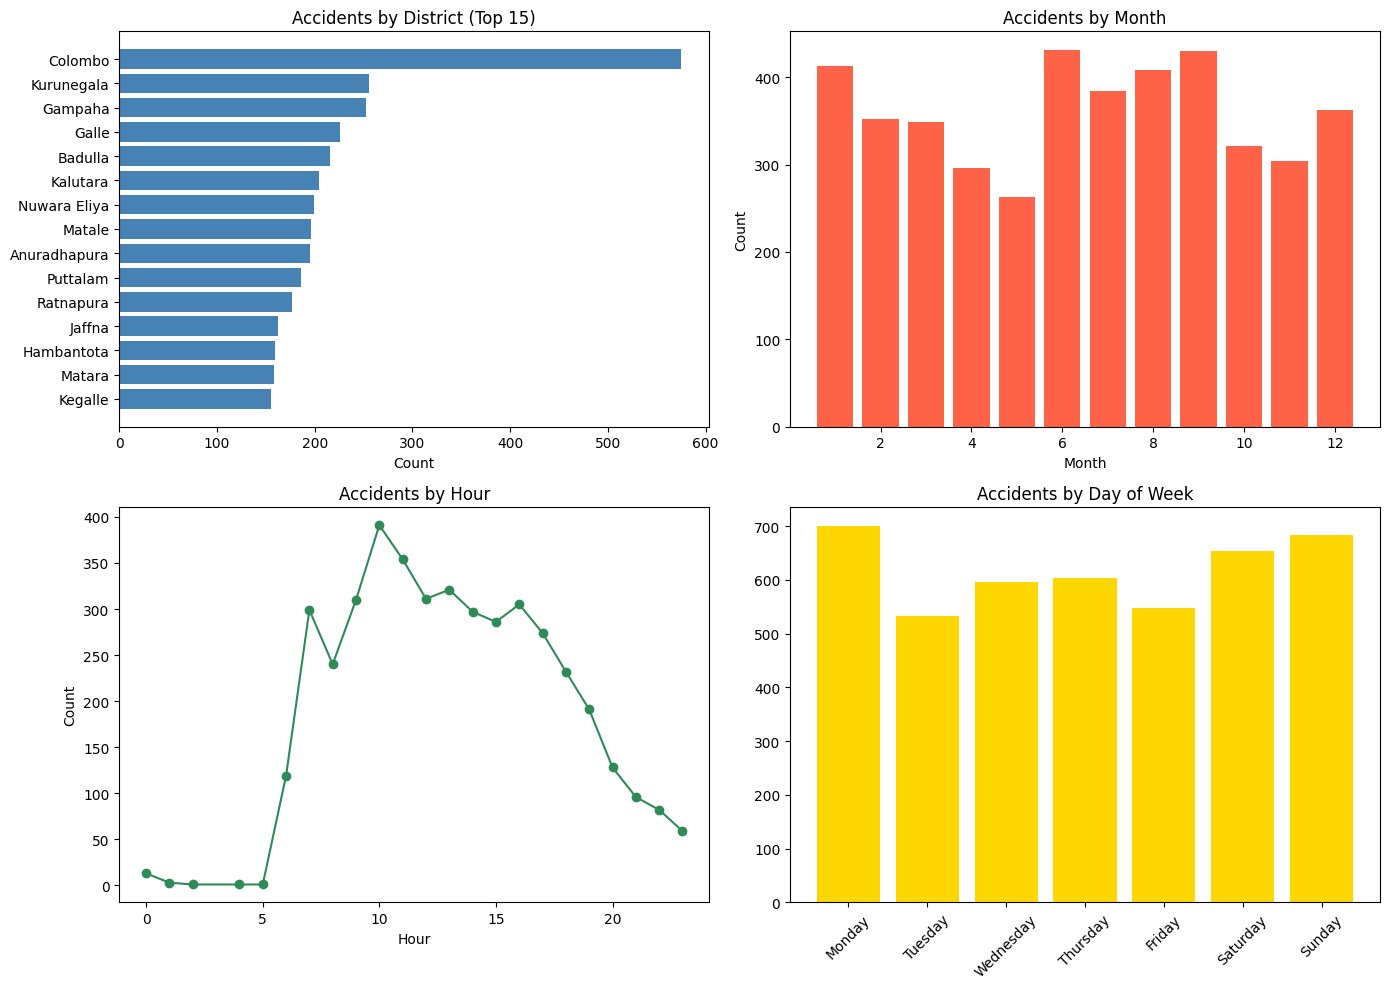

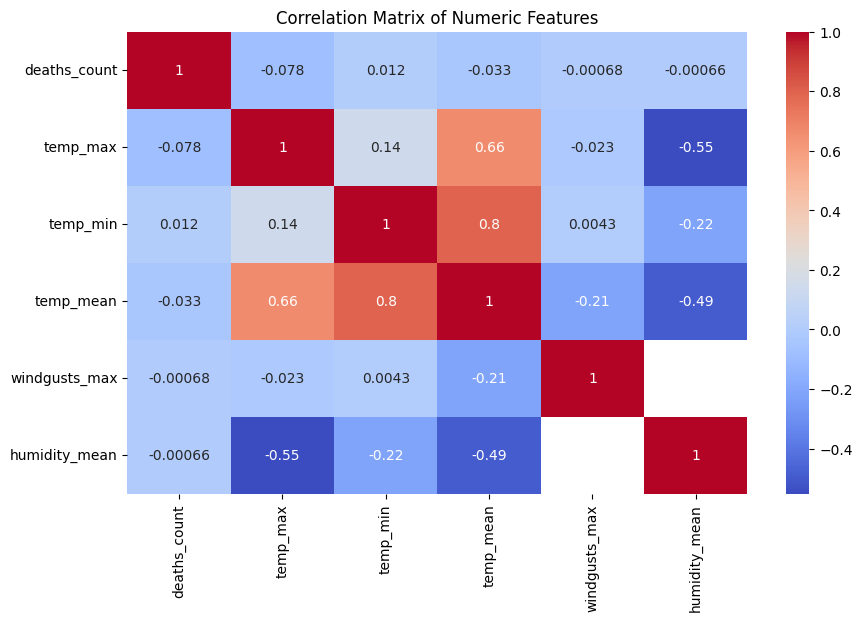

In [3]:
# DATA UNDERSTANDING
print(df.shape)
print(f'Column names {df.columns}')

# print(df.head())

# ========================= Data Visualization =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top = df['district'].value_counts().head(15)
axes[0, 0].barh(top.index[::-1], top.values[::-1], color='steelblue')
axes[0, 0].set_title('Accidents by District (Top 15)')
axes[0, 0].set_xlabel('Count')

month_counts = df['month'].value_counts().sort_index()
axes[0, 1].bar(month_counts.index, month_counts.values, color='tomato')
axes[0, 1].set_title('Accidents by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count')

hour_counts = df['hour'].value_counts().sort_index()
axes[1, 0].plot(hour_counts.index, hour_counts.values, marker='o', color='seagreen')
axes[1, 0].set_title('Accidents by Hour')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Count')

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(dow_order)
axes[1, 1].bar(dow_counts.index, dow_counts.values, color='gold')
axes[1, 1].set_title('Accidents by Day of Week')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

num_cols = ['deaths_count', 'temp_max', 'temp_min', 'temp_mean', 'windgusts_max', 'humidity_mean']
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()
# =====================================================================


In [4]:
# DATA CLEANING
print(f'Frist checking -  is there have a duplicated data \n duplicated data count : {df.duplicated().sum()} \n\n checking is there have nul values \n Null value counts : {df.isnull().sum()}' )

print(f'total data rows have : {df.shape[0]}')
print(f'total datacolumns can get after the data cleaning : {df.shape[0]}')

# DATA CLEANING
df = df.drop_duplicates()
df = df.dropna()

print(f'drop duplicates ✅')
print(f'drop null values ✅')


print(f'\n\n==========================================\nchecking : \n null value count : {df.isnull().sum()}\n duplicated value count : {df.duplicated().sum()}')

Frist checking -  is there have a duplicated data 
 duplicated data count : 0 

 checking is there have nul values 
 Null value counts : id               0
date             0
time             0
year             0
month            0
day              0
hour             0
day_of_week      0
district         0
city             0
latitude         0
longitude        0
deaths_count     0
weather_code     0
temp_max         0
temp_min         0
temp_mean        0
windgusts_max    0
humidity_mean    1
dtype: int64
total data rows have : 4314
total datacolumns can get after the data cleaning : 4314
drop duplicates ✅
drop null values ✅


checking : 
 null value count : id               0
date             0
time             0
year             0
month            0
day              0
hour             0
day_of_week      0
district         0
city             0
latitude         0
longitude        0
deaths_count     0
weather_code     0
temp_max         0
temp_min         0
temp_mean        0
windgusts_

In [5]:
# Count accidents per city
accident_count = df.groupby('city').size().reset_index(name='accident_count')

print("Accident count stats:")
print(accident_count['accident_count'].describe())

print("\nPercentiles:")
for p in [33, 50, 66, 75]:
    val = accident_count['accident_count'].quantile(p / 100)
    print(f"   {p}th: {val:.0f}")

# Assign risk
def assign_risk(count):
    if count <= 18:
        return "Low"
    elif count <= 45:
        return "Medium"
    else:
        return "High"

accident_count['risk_level'] = accident_count['accident_count'].apply(assign_risk)

# Merge
df = df.merge(accident_count[['city', 'accident_count', 'risk_level']], on='city', how='left')

print(f"\n📊 Risk Level Distribution:")
print(df['risk_level'].value_counts())

Accident count stats:
count    240.000000
mean      17.970833
std       13.474413
min       14.000000
25%       16.000000
50%       17.000000
75%       17.000000
max      220.000000
Name: accident_count, dtype: float64

Percentiles:
   33th: 16
   50th: 17
   66th: 17
   75th: 17

📊 Risk Level Distribution:
risk_level
Low       3699
Medium     394
High       220
Name: count, dtype: int64


In [6]:
# Encode day_of_week
from sklearn.preprocessing import LabelEncoder

le_day = LabelEncoder()
df['day_enc'] = le_day.fit_transform(df['day_of_week'].astype(str))

# Select features
feature_cols = [
    'hour', 'month', 'year',
    'deaths_count', 'weather_code',
    'temp_max', 'temp_min', 'temp_mean',
    'windgusts_max', 'humidity_mean',
    'day_enc'
]

X = df[feature_cols].fillna(0)
y = df['risk_level']

print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"\nFeatures: {feature_cols}")

X: (4313, 11)
y: (4313,)

Features: ['hour', 'month', 'year', 'deaths_count', 'weather_code', 'temp_max', 'temp_min', 'temp_mean', 'windgusts_max', 'humidity_mean', 'day_enc']


In [7]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nTrain distribution:")
print(y_train.value_counts())

# SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"\nBefore SMOTE: {Counter(y_train)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {Counter(y_train_res)}")

Train: (3450, 11)
Test:  (863, 11)

Train distribution:
risk_level
Low       2959
Medium     315
High       176
Name: count, dtype: int64

Before SMOTE: Counter({'Low': 2959, 'Medium': 315, 'High': 176})
After SMOTE:  Counter({'Low': 2959, 'Medium': 2959, 'High': 2959})


In [8]:
# Model
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=12,
    learning_rate=0.05,
    num_leaves=40,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# Train
model.fit(X_train_res, y_train_res)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.816917728852839
              precision    recall  f1-score   support

        High       0.40      0.48      0.43        44
         Low       0.90      0.89      0.90       740
      Medium       0.29      0.28      0.29        79

    accuracy                           0.82       863
   macro avg       0.53      0.55      0.54       863
weighted avg       0.82      0.82      0.82       863



In [9]:
import numpy as np
from sklearn.metrics import classification_report

y_proba = model.predict_proba(X_test)
classes = list(model.classes_)
print(f"Classes: {classes}")

# High + Medium indices
high_idx = classes.index('High')
medium_idx = classes.index('Medium')

# Best thresholds හොයන්න
best_macro_f1 = 0
best_h = 0.33
best_m = 0.33

for h_thresh in np.arange(0.20, 0.45, 0.02):
    for m_thresh in np.arange(0.20, 0.45, 0.02):
        y_pred_new = []
        for proba in y_proba:
            if proba[high_idx] >= h_thresh:
                y_pred_new.append('High')
            elif proba[medium_idx] >= m_thresh:
                y_pred_new.append('Medium')
            else:
                y_pred_new.append('Low')

        y_pred_new = np.array(y_pred_new)
        from sklearn.metrics import f1_score
        macro_f1 = f1_score(y_test, y_pred_new, average='macro')

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_h = h_thresh
            best_m = m_thresh

print(f"\n⭐ Best High threshold:   {best_h:.2f}")
print(f"⭐ Best Medium threshold: {best_m:.2f}")
print(f"⭐ Best Macro F1:         {best_macro_f1:.4f}")

# Final prediction with best thresholds
y_pred_final = []
for proba in y_proba:
    if proba[high_idx] >= best_h:
        y_pred_final.append('High')
    elif proba[medium_idx] >= best_m:
        y_pred_final.append('Medium')
    else:
        y_pred_final.append('Low')

y_pred_final = np.array(y_pred_final)

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(classification_report(y_test, y_pred_final))
print(f"Accuracy: {(y_pred_final == y_test).mean():.4f}")

Classes: ['High', 'Low', 'Medium']

⭐ Best High threshold:   0.40
⭐ Best Medium threshold: 0.44
⭐ Best Macro F1:         0.5375

FINAL RESULTS
              precision    recall  f1-score   support

        High       0.39      0.50      0.44        44
         Low       0.91      0.88      0.89       740
      Medium       0.26      0.30      0.28        79

    accuracy                           0.80       863
   macro avg       0.52      0.56      0.54       863
weighted avg       0.82      0.80      0.81       863

Accuracy: 0.8042


In [10]:
# ඔයාගේ දැනට තියෙන df එකේ columns බලන්න
print("Columns:", list(df.columns))
print("\nShape:", df.shape)
print("\nRisk Level Distribution:")
print(df['risk_level'].value_counts())

Columns: ['id', 'date', 'time', 'year', 'month', 'day', 'hour', 'day_of_week', 'district', 'city', 'latitude', 'longitude', 'deaths_count', 'weather_code', 'temp_max', 'temp_min', 'temp_mean', 'windgusts_max', 'humidity_mean', 'accident_count', 'risk_level', 'day_enc']

Shape: (4313, 22)

Risk Level Distribution:
risk_level
Low       3699
Medium     394
High       220
Name: count, dtype: int64


In [11]:
# ============================================================
# DATE + DISTRICT -> PER-DISTRICT RISK MODEL (time-varying)
# ============================================================
# Risk level of a district as of a date = its past-7-day accident
# load (Low/Medium/High). Features use ONLY data before the date,
# so this is a real, fully-causal forecast.

df['date'] = pd.to_datetime(df['date'])
df['district'] = df['district'].astype(str)

# Build a complete daily (date, district) grid
days = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
districts_sorted = sorted(df['district'].unique())
daily = pd.DataFrame([(d, dist) for d in days for dist in districts_sorted],
                     columns=['date', 'district'])
counts = df.groupby(['date', 'district']).size().reset_index(name='n')
daily = daily.merge(counts, on=['date', 'district'], how='left')
daily['n'] = daily['n'].fillna(0)
daily = daily.sort_values(['district', 'date']).reset_index(drop=True)
grp = daily.groupby('district')['n']

# Label: accident load of the 7 days BEFORE the date (known in the past)
daily['load7_prev'] = grp.transform(
    lambda s: s.rolling(7).sum().shift(1)).astype('float64')

def week_risk(load):
    if pd.isna(load) or load == 0:
        return 'Low'
    elif load <= 2:
        return 'Medium'
    return 'High'

daily['district_risk'] = daily['load7_prev'].map(week_risk)
print("District risk distribution (daily):")
print(daily['district_risk'].value_counts())

# Calendar features of the date
daily['year_d'] = daily['date'].dt.year
daily['month_d'] = daily['date'].dt.month
daily['day_d'] = daily['date'].dt.day
daily['dow_enc'] = le_day.transform(daily['date'].dt.day_name())

# District encoding
le_district = LabelEncoder()
daily['district_enc'] = le_district.fit_transform(daily['district'])

# Auto-regressive history features (strictly before the date)
daily['lag7']  = daily['load7_prev'].shift(7)     # 2 weeks back window
daily['lag14'] = daily['load7_prev'].shift(14)    # 3 weeks back window
daily['lag30'] = grp.transform(
    lambda s: s.rolling(30).sum().shift(1))       # last 30 days
daily['l1']    = grp.transform(lambda s: s.shift(1))  # yesterday

district_feats = ['year_d', 'month_d', 'day_d', 'dow_enc',
                  'district_enc', 'lag7', 'lag14', 'lag30', 'l1']

model_df = daily[daily['date'] >= df['date'].min() + pd.Timedelta(days=70)].copy()
model_df = model_df.dropna(subset=['lag7', 'lag14', 'lag30', 'l1'])

X = model_df[district_feats]
y = model_df['district_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

district_model = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    num_leaves=63,
    min_child_samples=15,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    reg_lambda=0.5
)
district_model.fit(X_train, y_train)

from sklearn.metrics import f1_score
y_pred = district_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

all_districts = districts_sorted
print(f"\nDistricts in model: {len(all_districts)}")

District risk distribution (daily):
district_risk
Low       54329
Medium    20126
High       1545
Name: count, dtype: int64
Accuracy: 0.7894
Macro F1: 0.7144

              precision    recall  f1-score   support

        High       0.45      0.87      0.59       300
         Low       0.99      0.74      0.85     10612
      Medium       0.57      0.92      0.70      3938

    accuracy                           0.79     14850
   macro avg       0.67      0.84      0.71     14850
weighted avg       0.87      0.79      0.80     14850


Districts in model: 25


In [12]:
def predict_district_risk(date_str):
    """
    Predict risk level (past-7-day load) for every district on a given date.
    Fully causal: only accident history BEFORE the date is used.
    Returns: {"Colombo": "High", "Gampaha": "Low", ...}
    """
    d = pd.to_datetime(date_str)
    hist = daily[daily['date'] < d]
    rows = []
    for dist in all_districts:
        h = hist[hist['district'] == dist]['n'].reset_index(drop=True)
        if len(h) == 0:
            l1 = lag7 = lag14 = lag30 = 0.0
        else:
            l1 = float(h.iloc[-1])      # yesterday (d-1)
            lag7 = float(h.iloc[-14:-7].sum())   # [d-14, d-8]
            lag14 = float(h.iloc[-21:-14].sum())  # [d-21, d-15]
            lag30 = float(h.tail(30).sum())      # [d-30, d-1]
        rows.append({'district': dist,
                     'year_d': d.year,
                     'month_d': d.month,
                     'day_d': d.day,
                     'dow_enc': le_day.transform([d.day_name()])[0],
                     'district_enc': le_district.transform([dist])[0],
                     'lag7': lag7, 'lag14': lag14, 'lag30': lag30, 'l1': l1})
    pred_df = pd.DataFrame(rows)
    preds = district_model.predict(pred_df[district_feats])
    return dict(zip(pred_df['district'], preds))

# Example - get the risk level for every district on a given date
result = predict_district_risk('2026-09-14')
print(result)

{'Ampara': 'Medium', 'Anuradhapura': 'Low', 'Badulla': 'Medium', 'Batticaloa': 'Low', 'Colombo': 'High', 'Galle': 'Low', 'Gampaha': 'Medium', 'Hambantota': 'Medium', 'Jaffna': 'Medium', 'Kalutara': 'Medium', 'Kandy': 'Medium', 'Kegalle': 'Medium', 'Kilinochchi': 'Low', 'Kurunegala': 'Medium', 'Mannar': 'High', 'Matale': 'Low', 'Matara': 'Low', 'Monaragala': 'Medium', 'Mullaitivu': 'Low', 'Nuwara Eliya': 'Low', 'Polonnaruwa': 'Low', 'Puttalam': 'Medium', 'Ratnapura': 'Low', 'Trincomalee': 'Medium', 'Vavuniya': 'Medium'}
